# 🛠️ K-Means Implementation in Python

In [2]:
from sklearn.datasets import make_blobs
import pandas as pd

X, _ = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=1.5,
    random_state=42
)

df = pd.DataFrame(
    X,
    columns=["Feature_1", "Feature_2"]
)

df.head()

,Feature_1,Feature_2
0,-7.114418,6.268758
1,-10.924957,-6.961552
2,7.924583,0.760722
3,-3.097360,6.819014
4,-5.077806,-7.492223


In [3]:
print(df.shape)
print(df.describe())

(500, 2)
        Feature_1   Feature_2
count  500.000000  500.000000
mean    -3.387676    2.908873
std      5.390165    6.454888
min    -11.214182  -10.196813
25%     -7.864795   -1.842668
50%     -4.811723    4.663269
75%      0.770736    8.301364
max      9.258200   14.793383


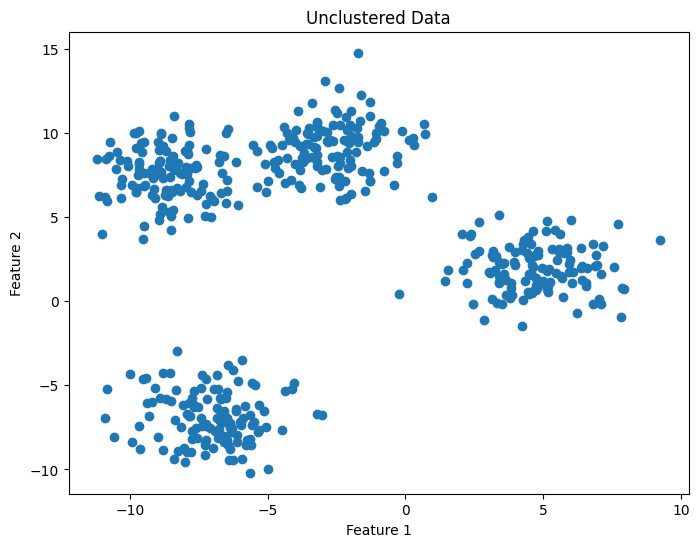

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Feature_1"],
    df["Feature_2"]
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Unclustered Data")

plt.show()

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [6]:
print(X_scaled.shape)

(500, 2)


### Create the K-Means model

In [7]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

In [8]:
kmeans.fit(X_scaled)

,n_clusters,4
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [9]:
labels = kmeans.labels_

print(labels[:20])

[1 2 0 3 2 2 3 2 0 2 0 3 0 3 2 0 3 1 1 3]


In [10]:
df["Cluster"] = labels

df.head()

,Feature_1,Feature_2,Cluster
0,-7.114418,6.268758,1
1,-10.924957,-6.961552,2
2,7.924583,0.760722,0
3,-3.097360,6.819014,3
4,-5.077806,-7.492223,2


In [11]:
print(df["Cluster"].value_counts().sort_index())

Cluster
0    125
1    124
2    125
3    126
Name: count, dtype: int64


In [12]:
centroids = kmeans.cluster_centers_

print(centroids)

[[ 1.51361513 -0.15657684]
 [-0.97604041  0.72037701]
 [-0.68228657 -1.52370499]
 [ 0.13581699  0.9580038 ]]


In [13]:
centroids_original = scaler.inverse_transform(
    centroids
)

print(centroids_original)

[[ 4.76279743  1.89919856]
 [-8.64343131  7.55417397]
 [-7.06163376 -6.91663151]
 [-2.65633217  9.08649366]]


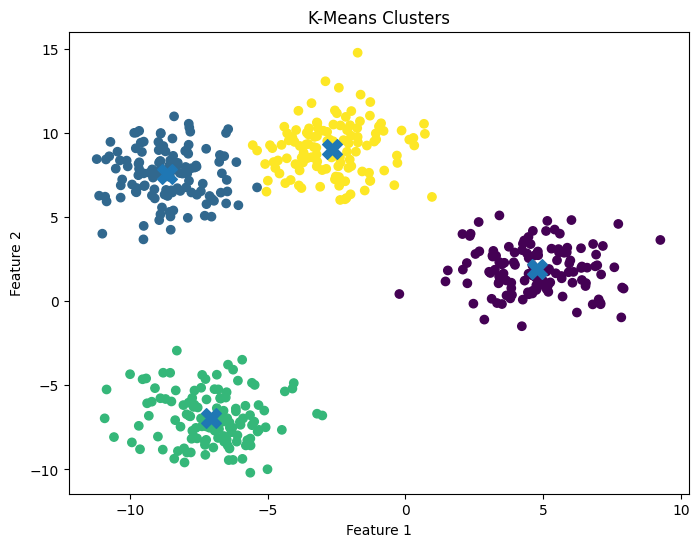

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Feature_1"],
    df["Feature_2"],
    c=df["Cluster"]
)

plt.scatter(
    centroids_original[:, 0],
    centroids_original[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clusters")

plt.show()

In [15]:
labels = kmeans.fit_predict(X_scaled)

In [16]:
kmeans.inertia_

61.716082577623204

In [17]:
centers_df = pd.DataFrame(
    centroids_original,
    columns=["Feature_1", "Feature_2"]
)

centers_df.index.name = "Cluster"

print(centers_df)

         Feature_1  Feature_2
Cluster                      
0         4.762797   1.899199
1        -8.643431   7.554174
2        -7.061634  -6.916632
3        -2.656332   9.086494


In [18]:
from sklearn.cluster import KMeans

inertias = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertias.append(kmeans.inertia_)

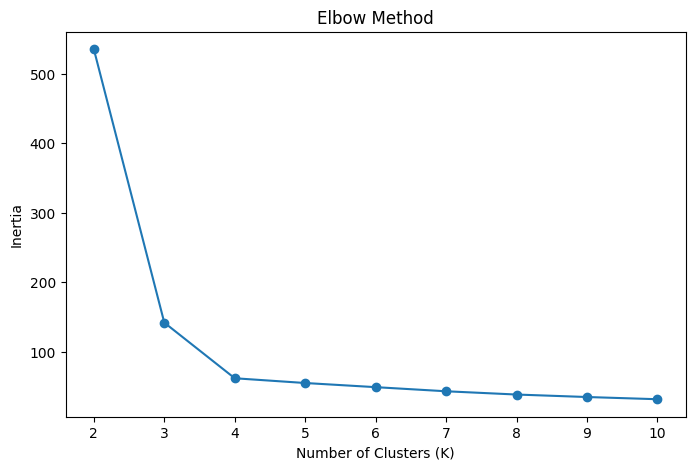

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [20]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    kmeans.labels_
)

print("Silhouette Score:", score)

Silhouette Score: 0.351567708630215


In [21]:
silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

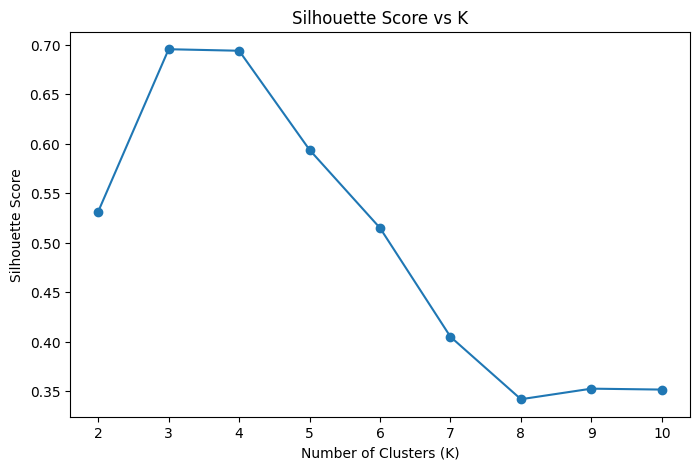

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")

plt.show()

### Calculate cluster profiles

In [23]:
cluster_profile = df.groupby("Cluster")[
    ["Feature_1", "Feature_2"]
].mean()

print(cluster_profile)

         Feature_1  Feature_2
Cluster                      
0         4.762797   1.899199
1        -8.643431   7.554174
2        -7.061634  -6.916632
3        -2.656332   9.086494


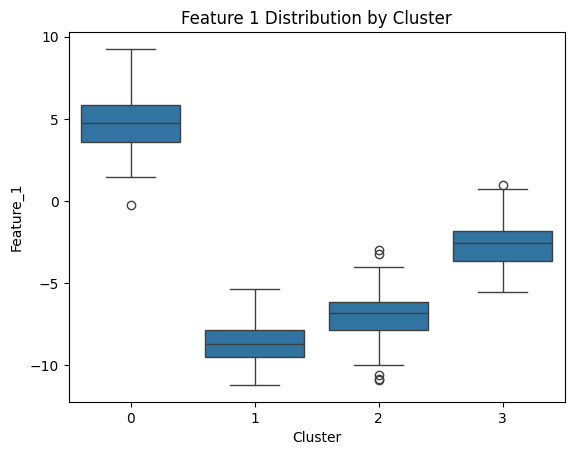

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df,
    x="Cluster",
    y="Feature_1"
)

plt.title("Feature 1 Distribution by Cluster")
plt.show()

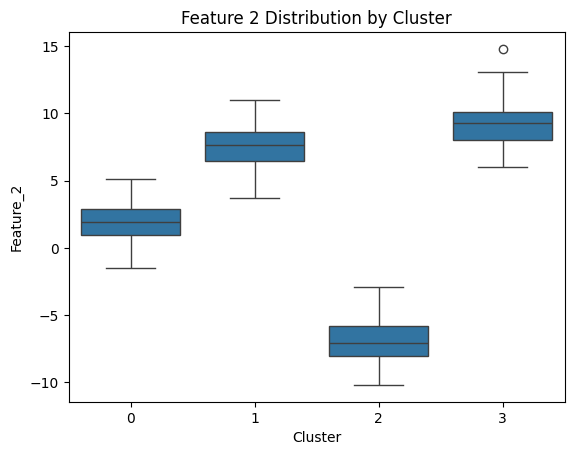

In [25]:
sns.boxplot(
    data=df,
    x="Cluster",
    y="Feature_2"
)

plt.title("Feature 2 Distribution by Cluster")
plt.show()

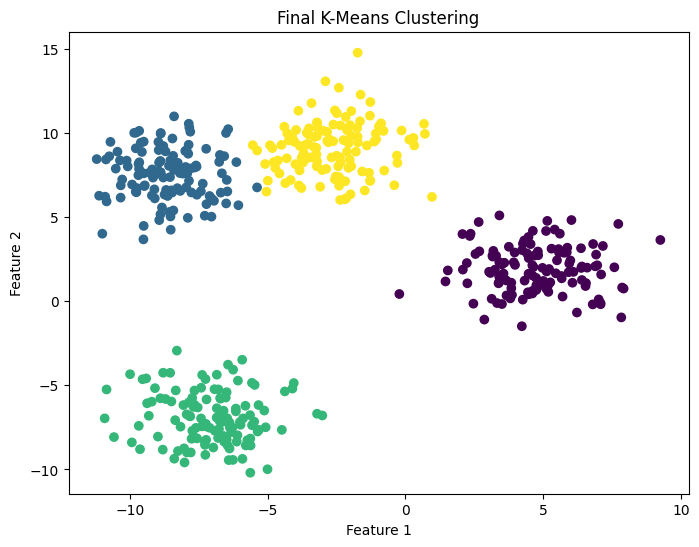

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Feature_1"],
    df["Feature_2"],
    c=df["Cluster"]
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Final K-Means Clustering")

plt.show()